In [1]:
import torch


In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [4]:
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.1MB/s]


In [6]:
class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FashionNet().to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
epochs = 10

In [14]:
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10] Loss: 0.2668
Epoch [2/10] Loss: 0.2526
Epoch [3/10] Loss: 0.2388
Epoch [4/10] Loss: 0.2272
Epoch [5/10] Loss: 0.2189
Epoch [6/10] Loss: 0.2069
Epoch [7/10] Loss: 0.1997
Epoch [8/10] Loss: 0.1882
Epoch [9/10] Loss: 0.1837
Epoch [10/10] Loss: 0.1710


In [15]:
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 94.26%


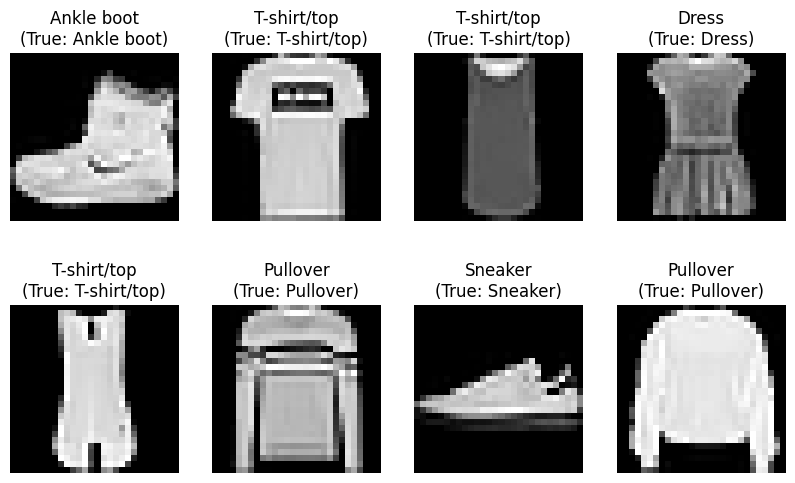

In [16]:
import matplotlib.pyplot as plt

classes = train_data.classes
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"{classes[preds[i]]}\n(True: {classes[labels[i]]})")
    plt.axis('off')
plt.show()

In [17]:
torch.save(model.state_dict(), 'fashion_mnist_net.pth')